In [1]:
import os
import mysql.connector
import pandas as pd

# List of CSV files and their corresponding table names
csv_files = [
    ("pizzas.csv", "pizzas"),
    ("orders.csv", "orders"),
    ("pizza_types.csv", "pizza_types"),
    ("order_details.csv", "orders_details"),
]

# Database Connection Credentials
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Ph2#Dr5$",  # Your MySQL password from screenshot
    database="pizzahut",
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = r"C:/Users/priya/OneDrive/Documents/Data analytics/SQL Notes and Projects/pizza_sales"


def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return "INT"
    elif pd.api.types.is_float_dtype(dtype):
        return "FLOAT"
    elif pd.api.types.is_bool_dtype(dtype):
        return "BOOLEAN"
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return "DATETIME"
    else:
        return "TEXT"


# Process each CSV file
for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)

    if not os.path.exists(file_path):
        print(f"File not found: {file_path}. Skipping...")
        continue

    # Read CSV with latin1 encoding to prevent UTF-8 errors
    df = pd.read_csv(file_path, encoding="latin1")

    # Clean column names (replace spaces, hyphens, and dots with underscores)
    df.columns = [
        col.replace(" ", "_").replace("-", "_").replace(".", "_")
        for col in df.columns
    ]

    # Generate CREATE TABLE statement dynamically
    col_definitions = ", ".join(
        [f"`{col}` {get_sql_type(df[col].dtype)}" for col in df.columns]
    )
    create_table_query = (
        f"CREATE TABLE IF NOT EXISTS `{table_name}` ({col_definitions})"
    )
    cursor.execute(create_table_query)

    # Insert Data into MySQL Table
    cols = ", ".join([f"`{col}`" for col in df.columns])
    placeholders = ", ".join(["%s"] * len(df.columns))
    sql = f"INSERT INTO `{table_name}` ({cols}) VALUES ({placeholders})"

    # Format values array safely for NaN/Null conversion
    data = [
        tuple(None if pd.isna(x) else x for x in row)
        for row in df.itertuples(index=False, name=None)
    ]

    # Bulk Insert (100x faster than iterrows loop)
    cursor.executemany(sql, data)
    conn.commit()

    print(f"Successfully imported {len(df)} rows into `{table_name}`")

# Close connection
cursor.close()
conn.close()
print("All CSV files processed successfully!")

Successfully imported 96 rows into `pizzas`
Successfully imported 21350 rows into `orders`
Successfully imported 32 rows into `pizza_types`
Successfully imported 48620 rows into `orders_details`
All CSV files processed successfully!


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import mysql.connector

db=mysql.connector.connect(host="localhost",username="root",password="Ph2#Dr5$",database="ecommerce")
cur=db.cursor()

# Retrieve the total number of orders placed.

In [29]:
query="""select count(order_id) from pizzahut.orders"""
cur.execute(query)
data=cur.fetchall()
data[0][0]

21350

# Calculate the total revenue generated from pizza sales.

In [30]:
query="""select round(sum(orders_details.quantity*pizzas.price),2) from pizzahut.orders_details
inner join pizzahut.pizzas 
on orders_details.pizza_id=pizzas.pizza_id"""
cur.execute(query)
data=cur.fetchall()
data[0][0]

817860.05

# Identify the highest-priced pizza.

In [31]:
query="""select pizza_types.name as pizza,pizzas.price from pizzahut.pizza_types
inner join pizzahut.pizzas
on pizza_types.pizza_type_id=pizzas.pizza_type_id order by price desc limit 1"""
cur.execute(query)
data=cur.fetchall()
data[0][0]

'The Greek Pizza'

# Identify the most common pizza size ordered.

In [32]:
query="""select pizzas.size,count(pizza_types.name) as number_of_pizzas from pizzahut.pizzas
inner join pizzahut.pizza_types
on pizza_types.pizza_type_id=pizzas.pizza_type_id
group by pizzas.size order by number_of_pizzas desc limit 1"""
cur.execute(query)
data=cur.fetchall()
data[0][0]

'S'

# List the top 5 most ordered pizza types along with their quantities.

                                    Pizza Name No. of ordered pizzas
0                     The Classic Deluxe Pizza                  2453
1                   The Barbecue Chicken Pizza                  2432
2                           The Hawaiian Pizza                  2422
3                          The Pepperoni Pizza                  2418
4                       The Thai Chicken Pizza                  2371
5                 The California Chicken Pizza                  2370
6                           The Sicilian Pizza                  1938
7                      The Spicy Italian Pizza                  1924
8                  The Southwest Chicken Pizza                  1917
9                           The Big Meat Pizza                  1914
10                       The Four Cheese Pizza                  1902
11                   The Italian Supreme Pizza                  1884
12           The Vegetables + Vegetables Pizza                  1526
13                          The Me

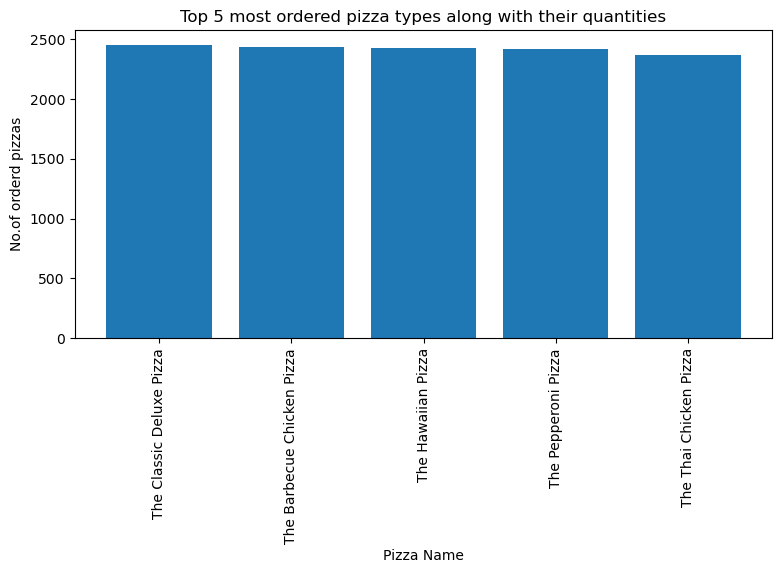

In [33]:
query="""select pizza_types.name,sum(orders_details.quantity) as number_of_pizzas from pizzahut.pizza_types 
inner join pizzahut.pizzas
on pizza_types.pizza_type_id=pizzas.pizza_type_id
inner join pizzahut.orders_details
on pizzas.pizza_id=orders_details.pizza_id group by pizza_types.name order by number_of_pizzas desc"""
cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["Pizza Name","No. of ordered pizzas"])
print(a)
a=a.sort_values(by="No. of ordered pizzas",ascending=False).head(5)
plt.figure(figsize=(9,4))
plt.bar(a["Pizza Name"],a["No. of ordered pizzas"])
plt.xticks(rotation=90)
plt.xlabel("Pizza Name")
plt.ylabel("No.of orderd pizzas")
plt.title("Top 5 most ordered pizza types along with their quantities")
plt.show()

# Join the necessary tables to find the total quantity of each pizza category ordered.

  Category No. of ordered pizzas
0  Classic                 14888
1  Supreme                 11987
2   Veggie                 11649
3  Chicken                 11050


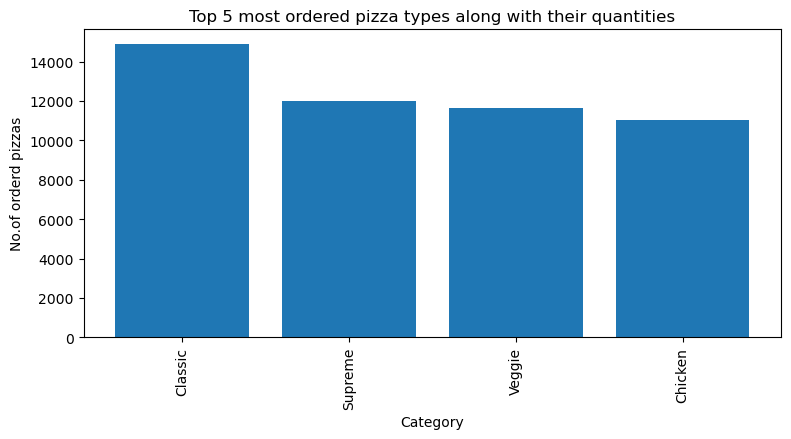

In [34]:
query="""select pizza_types.category,sum(orders_details.quantity) as number_of_pizzas from pizzahut.pizza_types 
inner join pizzahut.pizzas
on pizza_types.pizza_type_id=pizzas.pizza_type_id
inner join pizzahut.orders_details
on pizzas.pizza_id=orders_details.pizza_id group by pizza_types.category order by number_of_pizzas desc"""
cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["Category","No. of ordered pizzas"])
print(a)
a=a.sort_values(by="No. of ordered pizzas",ascending=False).head(5)
plt.figure(figsize=(9,4))
plt.bar(a["Category"],a["No. of ordered pizzas"])
plt.xticks(rotation=90)
plt.xlabel("Category")
plt.ylabel("No.of orderd pizzas")
plt.title("Top 5 most ordered pizza types along with their quantities")
plt.show()

# Determine the distribution of orders by hour of the day.

In [35]:
query="""select hour(orders.time),count(orders.order_id) from 
pizzahut.orders group by hour(orders.time)"""
cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["Hour","No. of orders"])
print(a)

    Hour  No. of orders
0     11           1231
1     12           2520
2     13           2455
3     14           1472
4     15           1468
5     16           1920
6     17           2336
7     18           2399
8     19           2009
9     20           1642
10    21           1198
11    22            663
12    23             28
13    10              8
14     9              1


# Join relevant tables to find the category-wise distribution of pizzas.

In [36]:
query="""select pizza_types.category,count(pizza_types.name) from
pizzahut.pizza_types group by pizza_types.category"""
cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["Category","Number of Types of pizzas"])
print(a)

  Category  Number of Types of pizzas
0  Chicken                          6
1  Classic                          8
2  Supreme                          9
3   Veggie                          9


# Group the orders by date and calculate the average number of pizzas ordered per day.

In [41]:
query="""select round(avg(quantity),0) from
(select orders.date,sum(orders_details.quantity) as quantity from 
pizzahut.orders inner join pizzahut.orders_details
on orders.order_id=orders_details.order_id group by orders.date) as order_quantity_per_day;"""
cur.execute(query)
data=cur.fetchall()
data[0][0]

Decimal('138')

# Determine the top 3 most ordered pizza types based on revenue.

In [45]:
query="""select pizza_types.name,sum(orders_details.quantity*pizzas.price) as revenue from pizzahut.pizza_types
inner join pizzahut.pizzas
on pizza_types.pizza_type_id=pizzas.pizza_type_id
inner join pizzahut.orders_details
on pizzas.pizza_id=orders_details.pizza_id group by pizza_types.name order by revenue desc"""
cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["Name","Revenue"])
a=a.sort_values(by="Revenue",ascending=False).head(3)
print(a)

                           Name   Revenue
0        The Thai Chicken Pizza  43434.25
1    The Barbecue Chicken Pizza  42768.00
2  The California Chicken Pizza  41409.50


# Calculate the percentage contribution of each pizza type to total revenue.

In [47]:
query="""select pizza_types.category,((sum(orders_details.quantity*pizzas.price)/(select round(sum(orders_details.quantity*pizzas.price),2) from pizzahut.orders_details
inner join pizzahut.pizzas 
on orders_details.pizza_id=pizzas.pizza_id))*100) as contribution_in_revenue from pizzahut.pizza_types
inner join pizzahut.pizzas
on pizza_types.pizza_type_id=pizzas.pizza_type_id
inner join pizzahut.orders_details
on pizzas.pizza_id=orders_details.pizza_id group by pizza_types.category order by contribution_in_revenue"""
cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["Category","Revenue Contribution"])
print(a)

  Category  Revenue Contribution
0   Veggie             23.682591
1  Chicken             23.955138
2  Supreme             25.456311
3  Classic             26.905960


# Analyze the cumulative revenue generated over time.

In [48]:
query="""select date,sum(revenue) 
over(order by date) as cumulative_revenue from
(select orders.date as date,sum(orders_details.quantity*pizzas.price) as revenue from pizzahut.orders
inner join pizzahut.orders_details
on orders.order_id=orders_details.order_id
inner join pizzahut.pizzas
on orders_details.pizza_id=pizzas.pizza_id group by orders.date) as a"""
cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["Date","Cumulative Revenue"])
print(a)

           Date  Cumulative Revenue
0    2015-01-01         2713.850002
1    2015-01-02         5445.750004
2    2015-01-03         8108.150007
3    2015-01-04         9863.600008
4    2015-01-05        11929.550009
..          ...                 ...
353  2015-12-27       810615.800827
354  2015-12-28       812253.000830
355  2015-12-29       813606.250832
356  2015-12-30       814944.050835
357  2015-12-31       817860.050838

[358 rows x 2 columns]


# Determine the top 3 most ordered pizza types based on revenue for each pizza category.

In [49]:
query="""select category,name,revenue from
(select category,name,revenue,rank()
over(partition by category order by revenue desc) as rn from 
(select pizza_types.category as category,pizza_types.name as name,sum(orders_details.quantity*pizzas.price) as revenue
from pizzahut.pizza_types inner join pizzahut.pizzas
on pizza_types.pizza_type_id=pizzas.pizza_type_id
inner join pizzahut.orders_details
on pizzas.pizza_id=orders_details.pizza_id group by pizza_types.category,pizza_types.name) as a) as b where rn<=3"""
cur.execute(query)
data=cur.fetchall()
a=pd.DataFrame(data,columns=["Category","Name","Revenue"])
print(a)

   Category                          Name       Revenue
0   Chicken        The Thai Chicken Pizza  43434.250000
1   Chicken    The Barbecue Chicken Pizza  42768.000000
2   Chicken  The California Chicken Pizza  41409.500000
3   Classic      The Classic Deluxe Pizza  38180.500000
4   Classic            The Hawaiian Pizza  32273.250000
5   Classic           The Pepperoni Pizza  30161.750000
6   Supreme       The Spicy Italian Pizza  34831.250000
7   Supreme     The Italian Supreme Pizza  33476.750000
8   Supreme            The Sicilian Pizza  30940.500000
9    Veggie         The Four Cheese Pizza  32265.701004
10   Veggie            The Mexicana Pizza  26780.750000
11   Veggie         The Five Cheese Pizza  26066.500000
